# Preparación de Imágenes - Actividades

Descripción de actividades enfocadas en procesamiento de imágenes.

## Actividad 1: Aumento de Datos
- Rotación, escalado, traslación y flip para ampliar dataset.

Carga una imagen `actividad4`.
Genera:
-  `3 rotaciones (diferentes ángulos)`
-  `2 escalados (zoom in / zoom out)`
-  `2 traslaciones`
-  `3 flips (vertical, horizontal, ambos)` 

Guarda todas las imágenes generadas en una carpeta actividad 4

Imports y configuración

In [197]:
import os
import cv2
import numpy as np

Crear carpeta de salida

In [198]:
output_dir = 'Actividad 4'

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

print(f"Carpeta lista: {output_dir}")

Carpeta lista: Actividad 4


Cargar imágenes

In [199]:
def rotate_image(image, angle):
    h, w = image.shape[:2]
    center = (w // 2, h // 2)

    matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(image, matrix, (w, h))

    return rotated

Función ROTACIÓN

In [200]:
image_paths = [
    r'C:\Users\User-PC\Documents\GitHub\Rulo\UNIDAD 3\HOY\actividad 4.png'
]

images = []

for path in image_paths:
    img = cv2.imread(path)
    if img is None:
        print(f"Error cargando: {path}")
    else:
        images.append((path, img))

print(f"Imágenes cargadas: {len(images)}")

Imágenes cargadas: 1


Función ESCALADO

In [201]:
def scale_image(image, scale):
    h, w = image.shape[:2]
    resized = cv2.resize(image, (int(w * scale), int(h * scale)))
    return resized

Función TRASLACIÓN

In [202]:
def translate_image(image, x, y):
    h, w = image.shape[:2]

    matrix = np.float32([
        [1, 0, x],
        [0, 1, y]
    ])

    translated = cv2.warpAffine(image, matrix, (w, h))
    return translated

Función FLIP

In [203]:
def flip_image(image, mode):
    return cv2.flip(image, mode)

Aplicar TODAS las transformaciones

In [204]:
for idx, (path, img) in enumerate(images):

    name = f"img_{idx}"

    #  ROTACIONES
    angles = [30, 60, 120]
    for i, angle in enumerate(angles):
        rotated = rotate_image(img, angle)
        cv2.imwrite(os.path.join(output_dir, f"{name}_rot_{i}.jpg"), rotated)

    #  ESCALADO
    scales = [1.2, 0.8]  # zoom in / zoom out
    for i, scale in enumerate(scales):
        scaled = scale_image(img, scale)
        cv2.imwrite(os.path.join(output_dir, f"{name}_scale_{i}.jpg"), scaled)

    # ↔ TRASLACIONES
    translations = [(50, 30), (-50, -30)]
    for i, (x, y) in enumerate(translations):
        translated = translate_image(img, x, y)
        cv2.imwrite(os.path.join(output_dir, f"{name}_trans_{i}.jpg"), translated)

    #  FLIPS
    flips = {
        "vertical": 0,
        "horizontal": 1,
        "both": -1
    }

    for key, mode in flips.items():
        flipped = flip_image(img, mode)
        cv2.imwrite(os.path.join(output_dir, f"{name}_flip_{key}.jpg"), flipped)

print("Todas las transformaciones completadas.")

Todas las transformaciones completadas.


## Actividad 2: Mejora de Imagen

Carga una imagen `actividad4` y `actividad4.1`

Aplica:

- `Conversión a escala de grises`
- `Ajuste de brillo y contraste con diferentes valores de alpha y beta`
- `Filtro Gaussiano`

In [205]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [206]:
output_dir = 'Actividad 4.2'

import os
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

print("Carpeta lista")

Carpeta lista


Cargar imágenes

In [207]:
img1 = cv2.imread('actividad 4.png')
img2 = cv2.imread('actividad4.2.jpg')

if img1 is None or img2 is None:
    print("Error cargando imágenes")
else:
    print("Imágenes cargadas correctamente")

Imágenes cargadas correctamente


Función para mostrar imágenes

In [208]:
def show(title, img):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.title(title)
    plt.axis('off')
    plt.show()

In [209]:
print(img1 is None)
print(img2 is None)

False
False


ESCALA DE GRISES

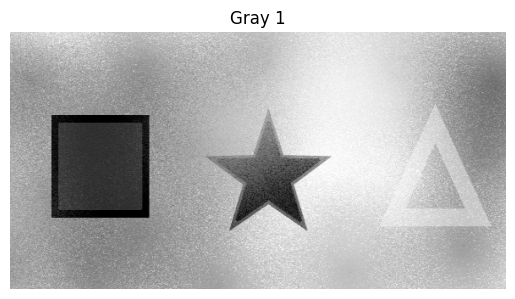

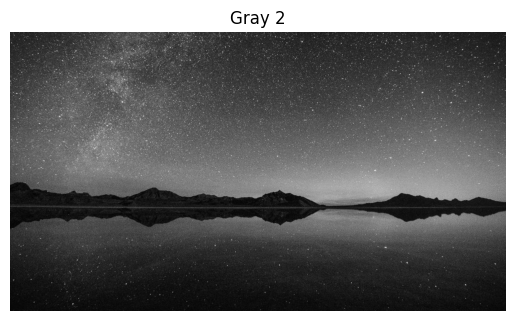

In [210]:
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

plt.imshow(gray1, cmap='gray')
plt.title("Gray 1")
plt.axis('off')
plt.show()

plt.imshow(gray2, cmap='gray')
plt.title("Gray 2")
plt.axis('off')
plt.show()

In [211]:
def adjust_brightness_contrast(image, alpha, beta):
    return cv2.convertScaleAbs(image, alpha=alpha, beta=beta)

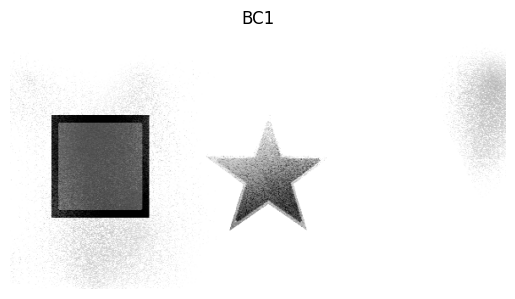

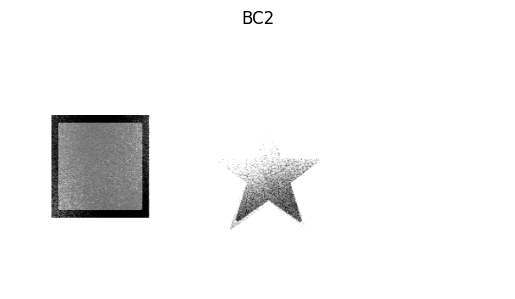

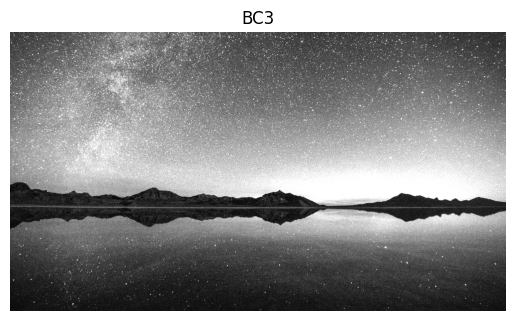

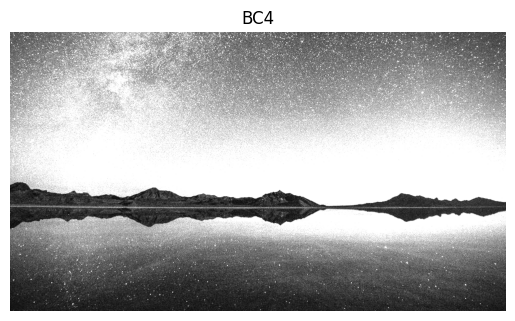

In [212]:
bc1 = adjust_brightness_contrast(gray1, alpha=1.5, beta=30)
bc2 = adjust_brightness_contrast(gray1, alpha=2.0, beta=50)

bc3 = adjust_brightness_contrast(gray2, alpha=1.5, beta=30)
bc4 = adjust_brightness_contrast(gray2, alpha=2.0, beta=50)

plt.imshow(bc1, cmap='gray')
plt.title("BC1")
plt.axis('off')
plt.show()

plt.imshow(bc2, cmap='gray')
plt.title("BC2")
plt.axis('off')
plt.show()

plt.imshow(bc3, cmap='gray')
plt.title("BC3")
plt.axis('off')
plt.show()

plt.imshow(bc4, cmap='gray')
plt.title("BC4")
plt.axis('off')
plt.show()

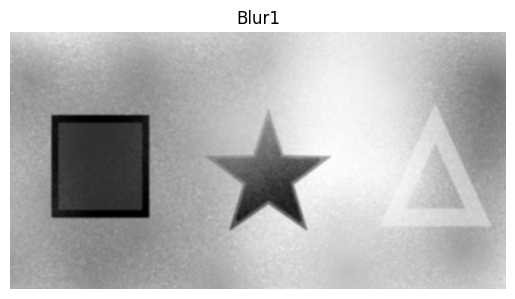

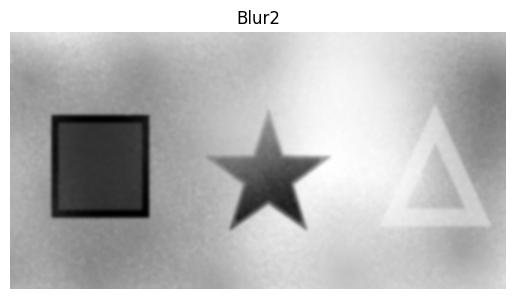

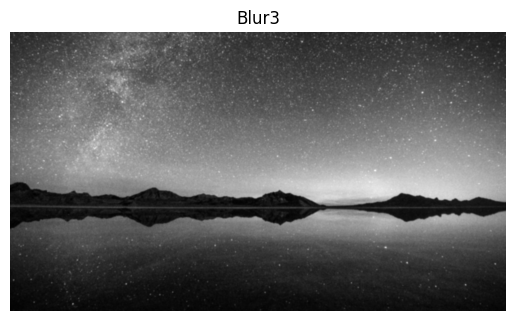

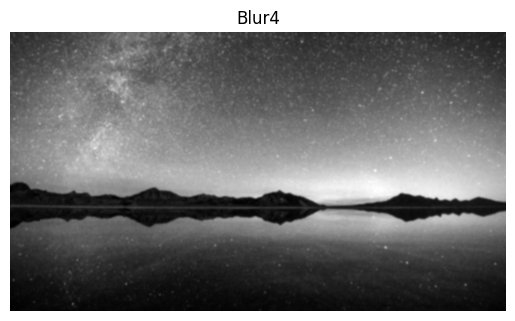

In [213]:
blur1 = cv2.GaussianBlur(gray1, (5,5), 0)
blur2 = cv2.GaussianBlur(gray1, (9,9), 0)

blur3 = cv2.GaussianBlur(gray2, (5,5), 0)
blur4 = cv2.GaussianBlur(gray2, (9,9), 0)

plt.imshow(blur1, cmap='gray')
plt.title("Blur1")
plt.axis('off')
plt.show()

plt.imshow(blur2, cmap='gray')
plt.title("Blur2")
plt.axis('off')
plt.show()

plt.imshow(blur3, cmap='gray')
plt.title("Blur3")
plt.axis('off')
plt.show()

plt.imshow(blur4, cmap='gray')
plt.title("Blur4")
plt.axis('off')
plt.show()

In [214]:
cv2.imwrite(os.path.join(output_dir, 'gray1.jpg'), gray1)
cv2.imwrite(os.path.join(output_dir, 'gray2.jpg'), gray2)

True

In [215]:
cv2.imwrite(os.path.join(output_dir, 'bc1.jpg'), bc1)
cv2.imwrite(os.path.join(output_dir, 'bc2.jpg'), bc2)
cv2.imwrite(os.path.join(output_dir, 'bc3.jpg'), bc3)
cv2.imwrite(os.path.join(output_dir, 'bc4.jpg'), bc4)

True

In [216]:
cv2.imwrite(os.path.join(output_dir, 'blur1.jpg'), blur1)
cv2.imwrite(os.path.join(output_dir, 'blur2.jpg'), blur2)
cv2.imwrite(os.path.join(output_dir, 'blur3.jpg'), blur3)
cv2.imwrite(os.path.join(output_dir, 'blur4.jpg'), blur4)

True

## Actividad 3: Mejora de Imagen

Carga una imagen de la carpera frutas

### Por cada imagen:

Genera
- `2 rotaciones`
- `1 escalado`
- `1 flip`

Aplica:

- `Conversión a escala de grises`
- `Ajuste de brillo y contraste con diferentes valores de alpha y beta`
- `Filtro Gaussiano` 

Convierte las imágenes a espacio HSV
Define rangos de color según el objeto de interés

Genera:
`Máscara binaria`
`Imagen segmentada`

Para cada imagen segmentada:
- `Aplica umbralización`
- `Detecta contornos usando al menos:`
- `Dibuja los contornos sobre la imagen original`

Imports

In [217]:
import cv2
import numpy as np
import os

Crear carpeta

In [218]:
output_dir = 'Actividad 4.3'

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

print("Carpeta lista")

Carpeta lista


Cargar imágenes

In [219]:
image_paths = [
    'frutas/Image_1.jpg',
    'frutas/Image_2.jpg',
    'frutas/Image_3.jpg',
    'frutas/Image_4.jpg',
    'frutas/Image_5.jpg',

]

images = []

for path in image_paths:
    img = cv2.imread(path)
    if img is None:
        print(f"Error cargando: {path}")
    else:
        images.append((path, img))

print(f"Imágenes cargadas: {len(images)}")

Imágenes cargadas: 5


FUNCIONES

In [220]:
def rotate(img, angle):
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1)
    return cv2.warpAffine(img, M, (w, h))

def scale(img, factor):
    return cv2.resize(img, None, fx=factor, fy=factor)

def flip(img):
    return cv2.flip(img, 1)

def adjust(img, alpha, beta):
    return cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

PROCESAMIENTO 

In [221]:
for idx, (path, img) in enumerate(images):

    name = f"img_{idx}"


    rot1 = rotate(img, 30)
    rot2 = rotate(img, -30)
    fl = flip(img)

    transformed = [img, rot1, rot2, fl]

    for j, im in enumerate(transformed):

        tag = f"{name}_{j}"

    
        gray = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)

      
        blur = cv2.GaussianBlur(gray, (5,5), 0)


        bc = adjust(blur, 1.8, 40)

   
        if j == 0:  
            hsv = cv2.cvtColor(im, cv2.COLOR_BGR2HSV)

            lower = np.array([20, 100, 100])
            upper = np.array([35, 255, 255])

            mask = cv2.inRange(hsv, lower, upper)
            segmented = cv2.bitwise_and(im, im, mask=mask)

  
        _, thresh = cv2.threshold(bc, 100, 255, cv2.THRESH_BINARY)

        
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        cont_img = im.copy()
        cv2.drawContours(cont_img, contours, -1, (0,255,0), 2)

       
        if j == 0:
      
            cv2.imwrite(os.path.join(output_dir, f"{tag}_gray.jpg"), gray)
            cv2.imwrite(os.path.join(output_dir, f"{tag}_bc.jpg"), bc)
            cv2.imwrite(os.path.join(output_dir, f"{tag}_cont.jpg"), cont_img)
        else:
            
            cv2.imwrite(os.path.join(output_dir, f"{tag}_cont.jpg"), cont_img)

print("Proceso balanceado ")

Proceso balanceado 
